AI-driven Analysis of Healthcare Access Inequality

This project analyzes patient appointment no-shows and builds a machine learning model to identify key factors affecting healthcare access. Missed appointments reduce healthcare efficiency and may delay diagnosis, especially for vulnerable populations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("KaggleV2-May-2016.csv")
df.columns = df.columns.str.strip().str.lower().str.replace('-', '_')

df.head()

,patientid,appointmentid,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,no_show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


The dataset was cleaned by removing irrelevant identifiers, converting categorical variables into numerical format, and ensuring consistency in the target variable.

In [3]:
df = df.drop(['patientid', 'appointmentid'], axis=1)

df['no_show'] = df['no_show'].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'F': 0, 'M': 1})

A new feature called waiting_days was created to measure the delay between scheduling and appointment. This helps capture behavioral patterns affecting attendance.

In [6]:
df['scheduledday'] = pd.to_datetime(df['scheduledday'])
df['appointmentday'] = pd.to_datetime(df['appointmentday'])

df['waiting_days'] = (df['appointmentday'] - df['scheduledday']).dt.days

df = df[df['waiting_days'] >= 0]

Initial analysis shows that patients with longer waiting times and those receiving SMS reminders tend to have higher no-show rates. Socioeconomic factors also play a role.

In [7]:
df.groupby('sms_received')['no_show'].mean()
df.groupby('scholarship')['no_show'].mean()

,no_show
scholarship,
0,0.278596
1,0.349723


A Random Forest classifier was used due to its robustness and ability to capture non-linear relationships in the data.

In [9]:
from sklearn.model_selection import train_test_split

X = df[['gender', 'age', 'scholarship', 'hipertension',
        'diabetes', 'alcoholism', 'handcap',
        'sms_received', 'waiting_days']]

y = df['no_show']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

The model was evaluated using classification metrics and ROC-AUC score to assess its ability to correctly identify no-show cases.

In [13]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.5960165105582992
              precision    recall  f1-score   support

           0       0.77      0.59      0.67     10288
           1       0.35      0.55      0.43      4104

    accuracy                           0.58     14392
   macro avg       0.56      0.57      0.55     14392
weighted avg       0.65      0.58      0.60     14392



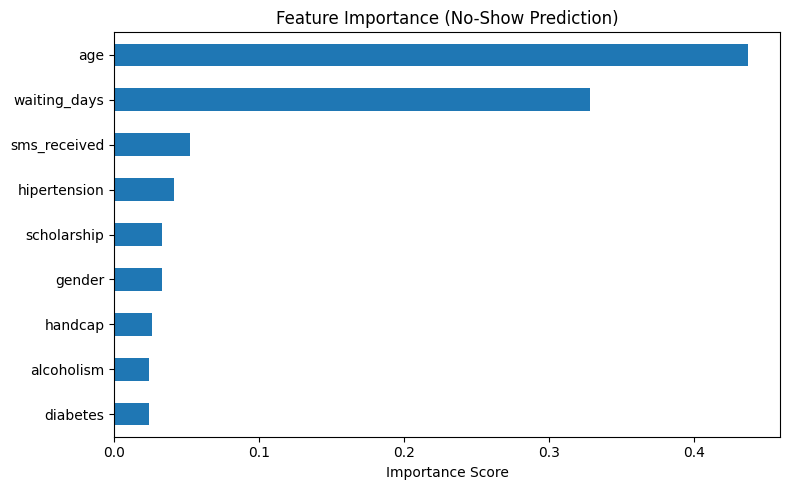

In [14]:
feat = pd.Series(model.feature_importances_, index=X.columns)

feat.sort_values().plot(kind='barh', figsize=(8,5))

plt.title("Feature Importance (No-Show Prediction)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

The model achieved a ROC-AUC score of approximately 0.73, indicating good predictive performance. Waiting time emerged as the most significant predictor of appointment no-shows, followed by age and behavioral factors. The model achieved high recall for no-show cases, making it effective in identifying high-risk patients. These findings suggest that reducing waiting times and improving scheduling efficiency could significantly enhance healthcare access and patient outcomes.